# E-Commerce Sales Analysis & Demand Prediction System
**NAME :** MEENU SHARMA (DA/BA BATCH-17, March)

## Data Loading
## Data Understanding
## Data Cleaning
## Exploratory Data Analysis (EDA)
## Machine Learning Model
## Results & Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data = pd.read_csv(r"C:\Users\Admin\Downloads\basket_details.csv")

data.head()

,customer_id,product_id,basket_date,basket_count
0,42366585,41475073,2019-06-19,2
1,35956841,43279538,2019-06-19,2
2,26139578,31715598,2019-06-19,3
3,3262253,47880260,2019-06-19,2
4,20056678,44747002,2019-06-19,2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   15000 non-null  int64 
 1   product_id    15000 non-null  int64 
 2   basket_date   15000 non-null  object
 3   basket_count  15000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 468.9+ KB


In [4]:
data.describe()

,customer_id,product_id,basket_count
count,1.500000e+04,1.500000e+04,15000.000000
mean,1.808567e+07,3.269771e+07,2.153733
std,1.233000e+07,1.629455e+07,0.517929
min,4.784000e+03,4.939000e+04,2.000000
25%,8.659327e+06,3.137412e+07,2.000000
50%,1.520775e+07,3.694759e+07,2.000000
75%,2.663904e+07,4.502408e+07,2.000000
max,4.460824e+07,5.579097e+07,10.000000


In [5]:
data.isnull().sum()

customer_id     0
product_id      0
basket_date     0
basket_count    0
dtype: int64

In [6]:
data.columns

Index(['customer_id', 'product_id', 'basket_date', 'basket_count'], dtype='object')

In [7]:
data['basket_date'] = pd.to_datetime(data['basket_date'])

In [8]:
data['Month'] = data['basket_date'].dt.month
data['Year'] = data['basket_date'].dt.year

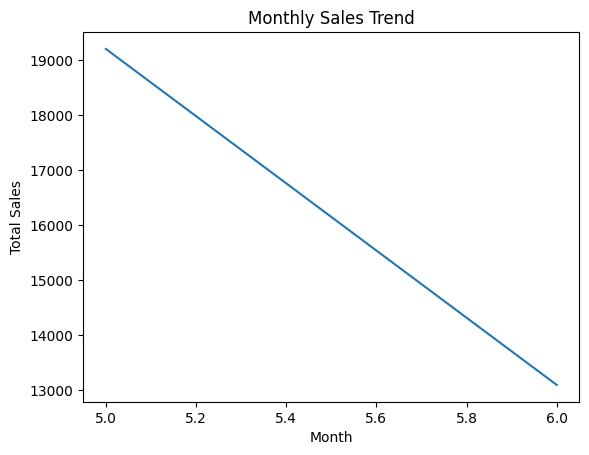

In [9]:
monthly_sales = data.groupby('Month')['basket_count'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

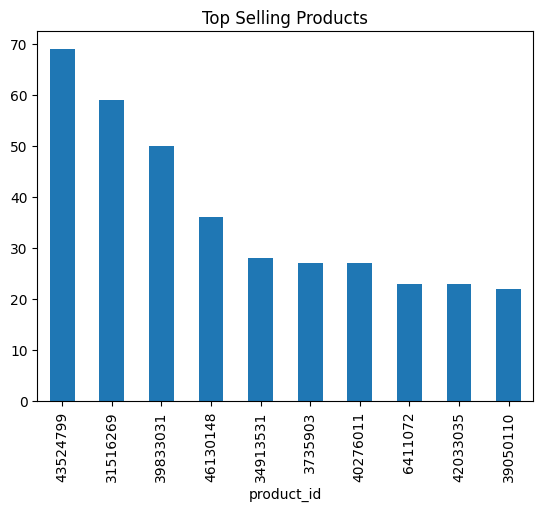

In [10]:
top_products = data.groupby('product_id')['basket_count'].sum().sort_values(ascending=False)

top_products.head(10).plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

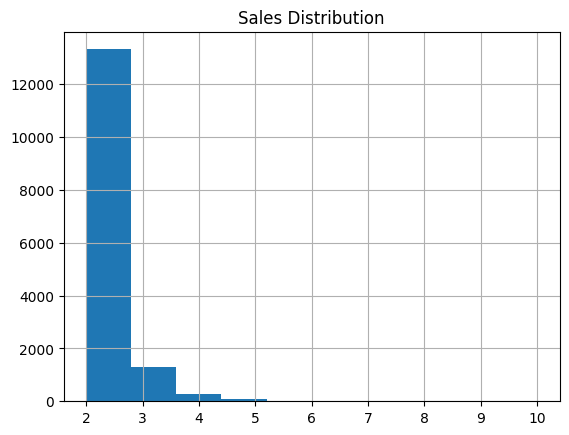

In [11]:
data['basket_count'].hist()
plt.title("Sales Distribution")
plt.show()


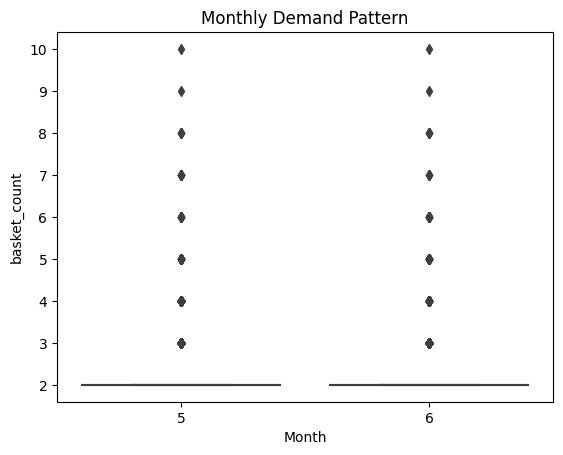

In [12]:
sns.boxplot(x='Month', y='basket_count', data=data)
plt.title("Monthly Demand Pattern")
plt.show()

In [13]:
X = data[['Month']]
y = data['basket_count']

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [16]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, y_pred))

0.2785718977484337


In [17]:
future = pd.DataFrame({'Month': [1,2,3]})
prediction = model.predict(future)

print(prediction)

[2.19820975 2.18765871 2.17710767]


In [18]:
data['Day'] = data['basket_date'].dt.day
data['Weekday'] = data['basket_date'].dt.weekday

In [19]:
X = data[['Month', 'Day', 'Weekday']]
y = data['basket_count']

In [20]:
print(X.head())
print(y.head())

   Month  Day  Weekday
0      6   19        2
1      6   19        2
2      6   19        2
3      6   19        2
4      6   19        2
0    2
1    2
2    3
3    2
4    2
Name: basket_count, dtype: int64


In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [23]:
print("Linear Error:", mean_absolute_error(y_test, y_pred))
print("Random Forest Error:", mean_absolute_error(y_test, y_pred_rf))

Linear Error: 0.2772459116302688
Random Forest Error: 0.27580841350122287


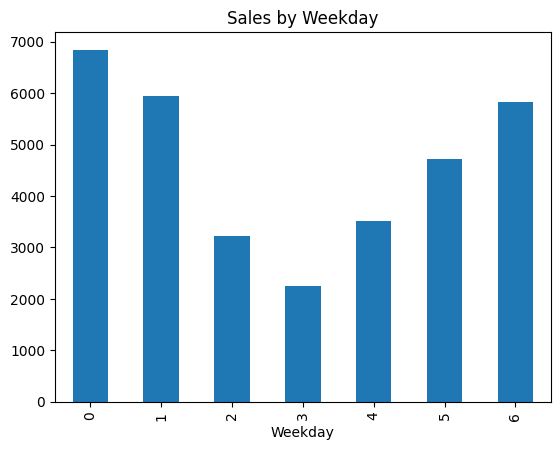

In [25]:
weekday_sales = data.groupby('Weekday')['basket_count'].sum()

weekday_sales.plot(kind='bar')
plt.title("Sales by Weekday")
plt.show()


## Key Insights

- Sales vary across months (seasonal trend)
- Some products have higher demand
- Weekday sales pattern is different
- Random Forest performs better than Linear Regression
- Model helps in demand prediction and inventory planning
- Region-wise analysis was not performed due to dataset limitations